# Chapter 07 - Unsupervised Learning

## Objectives
Learn methods for discovering hidden structure without labels. Covers PCA, K-Means, hierarchical clustering, silhouette analysis, and Gaussian mixture models.

## Core Theory
Unsupervised learning finds patterns when no target variable exists. It is useful for segmentation, anomaly screening, compression, recommendation, and exploratory discovery.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage
sns.set_theme(style='whitegrid')
np.random.seed(42)

In [2]:
X,y=make_blobs(n_samples=500,centers=4,n_features=5,cluster_std=[1.2,1.8,1.0,1.5],random_state=42)
X=StandardScaler().fit_transform(X)

## 1. PCA (Principal Component Analysis)
Reduces dimensions while preserving maximum variance.

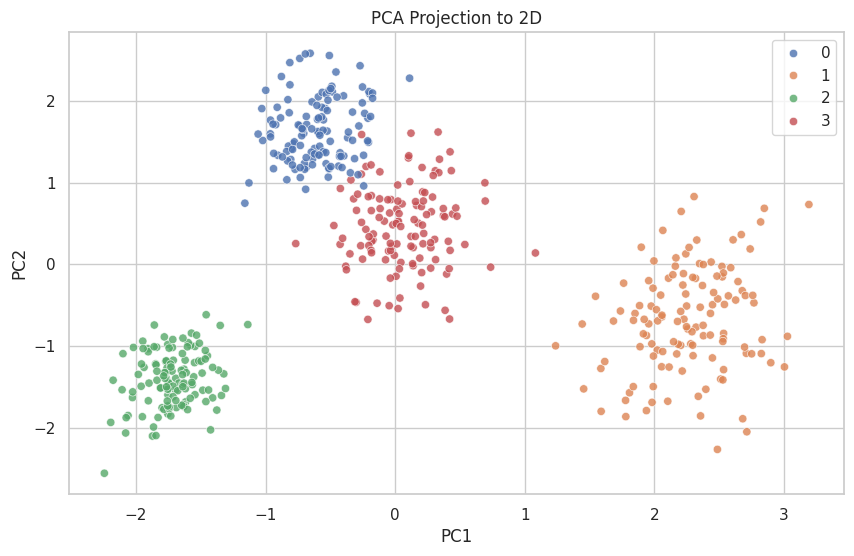

In [3]:
pca=PCA(n_components=2)
Xp=pca.fit_transform(X)
plt.figure(figsize=(10,6))
sns.scatterplot(x=Xp[:,0],y=Xp[:,1],hue=y,palette='deep',alpha=.8)
plt.title('PCA Projection to 2D')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.show()

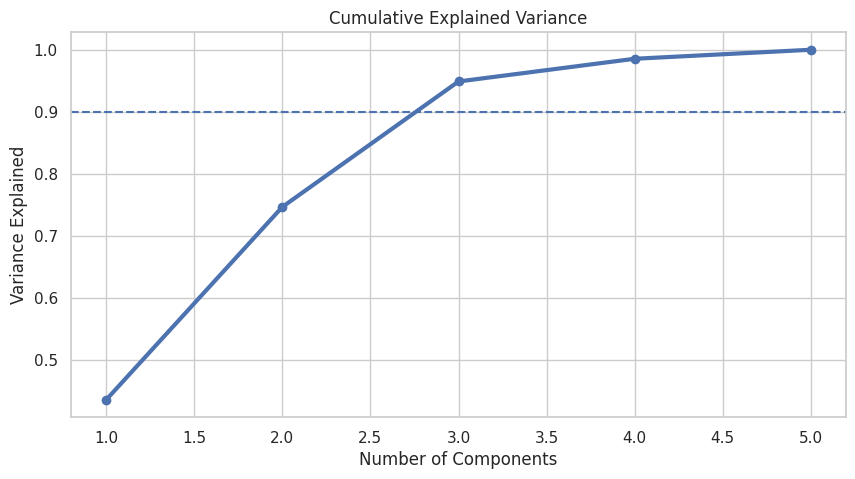

In [4]:
evr=np.cumsum(PCA().fit(X).explained_variance_ratio_)
plt.figure(figsize=(10,5))
plt.plot(range(1,len(evr)+1),evr,marker='o',lw=3)
plt.axhline(0.9,ls='--')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components'); plt.ylabel('Variance Explained')
plt.show()

## 2. K-Means Clustering
Partitions data into K groups by minimizing within-cluster distance.

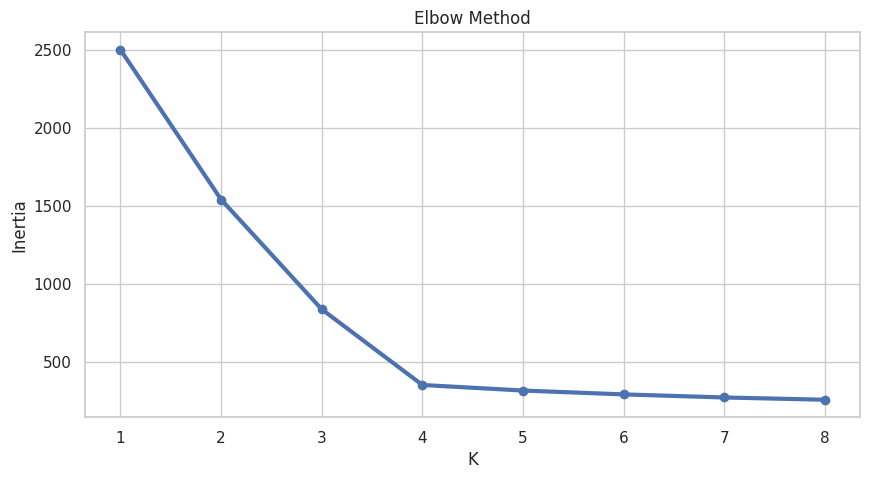

In [5]:
inertia=[]
ks=range(1,9)
for k in ks:
    km=KMeans(n_clusters=k,n_init=10,random_state=42).fit(X)
    inertia.append(km.inertia_)
plt.figure(figsize=(10,5))
plt.plot(list(ks),inertia,marker='o',lw=3)
plt.title('Elbow Method')
plt.xlabel('K'); plt.ylabel('Inertia')
plt.show()

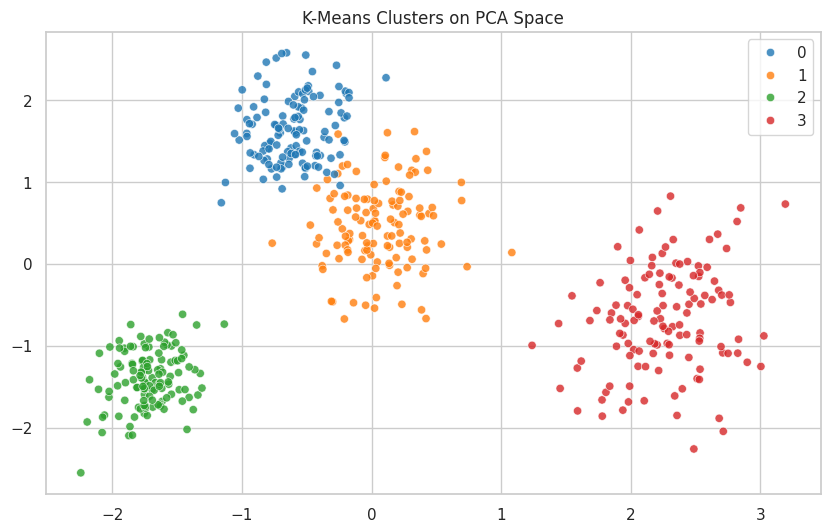

In [6]:
km=KMeans(n_clusters=4,n_init=10,random_state=42).fit(X)
labels=km.labels_
plt.figure(figsize=(10,6))
sns.scatterplot(x=Xp[:,0],y=Xp[:,1],hue=labels,palette='tab10',alpha=.8)
plt.title('K-Means Clusters on PCA Space')
plt.show()

## 3. Silhouette Analysis
Measures how well observations fit their assigned cluster.

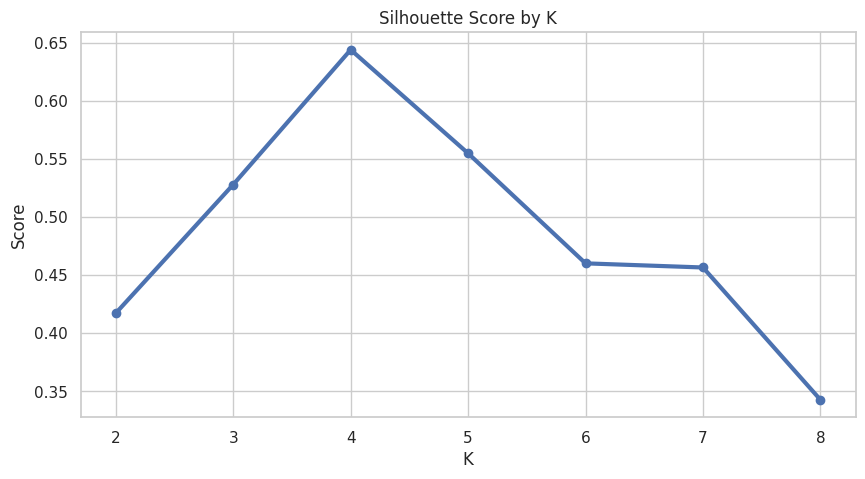

In [7]:
scores=[]
for k in range(2,9):
    lab=KMeans(n_clusters=k,n_init=10,random_state=42).fit_predict(X)
    scores.append(silhouette_score(X,lab))
plt.figure(figsize=(10,5))
plt.plot(range(2,9),scores,marker='o',lw=3)
plt.title('Silhouette Score by K')
plt.xlabel('K'); plt.ylabel('Score')
plt.show()

## 4. Hierarchical Clustering
Builds nested clusters; dendrogram visualizes merges.

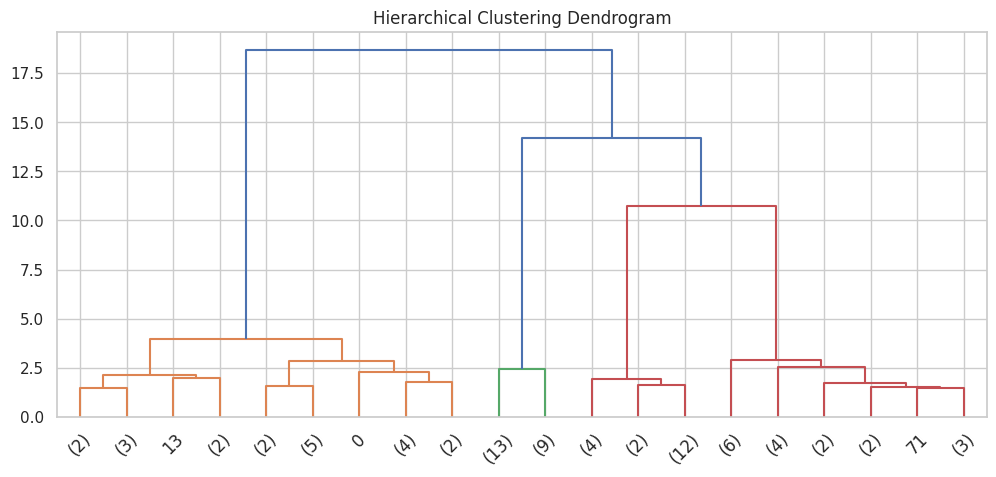

In [8]:
Z=linkage(X[:80],method='ward')
plt.figure(figsize=(12,5))
dendrogram(Z,truncate_mode='lastp',p=20,leaf_rotation=45)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

## 5. Gaussian Mixture Models
Soft clustering with probability membership.

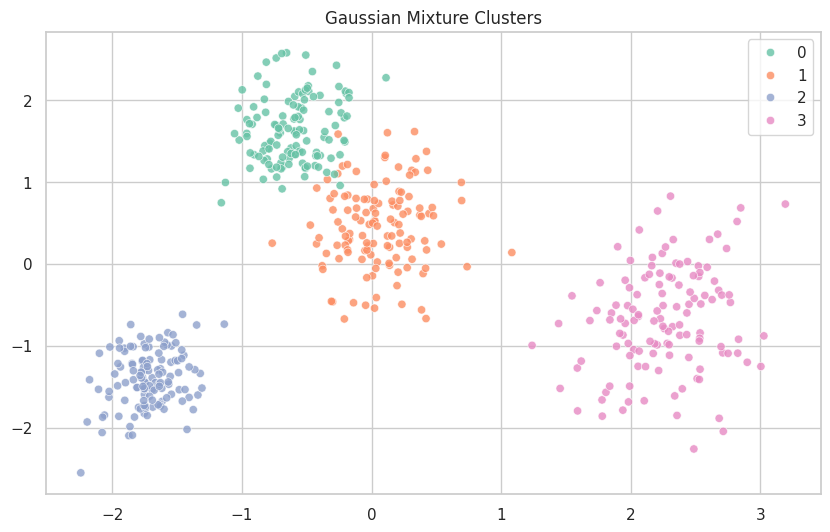

In [9]:
gmm=GaussianMixture(n_components=4,random_state=42).fit(X)
glabels=gmm.predict(X)
plt.figure(figsize=(10,6))
sns.scatterplot(x=Xp[:,0],y=Xp[:,1],hue=glabels,palette='Set2',alpha=.8)
plt.title('Gaussian Mixture Clusters')
plt.show()

## Key Concepts
- Scaling matters before clustering.
- PCA aids visualization and compression.
- K-Means assumes roughly spherical clusters.
- Hierarchical clustering gives tree structure.
- Mixture models allow probabilistic membership.
- Cluster labels are algorithmic, not ground truth.

## Key Takeaways
1. Unsupervised learning discovers structure without labels.
2. PCA simplifies high-dimensional data.
3. Use elbow + silhouette to choose K.
4. Compare multiple clustering methods.
5. Interpret clusters with domain knowledge.